# Data Cleaning
    - Data Type Issues 
    - Missing Values
    - Duplicate Values
    - Outlier Values
    - Misc issues

In [60]:
import pandas as pd

In [61]:
data = pd.read_excel("employee.xlsx")

In [62]:
data

,Serial,Emp_ID,Designation,Department,Age,Salary
0,1,1101,Manager,Accounts,50.0,200000.0
1,2,1107,Officer,IT,30.0,80000.0
2,3,1203,Officer,HR,28.0,NaN
3,4,1005,Manager,HR,45.0,120000.0
4,5,2123,Office Boy,Accounts,27.0,45000.0
5,6,2451,Accountant,NaN,34.0,100000.0
6,7,1111,Accountant,Accounts,NaN,110000.0
7,8,1001,Officer,IT,25.0,75000.0
8,9,1234,Manager,IT,23.0,NaN
9,10,2156,Engineer,Production,45.0,89000.0


In [63]:
data.drop('Serial', axis=1,inplace=True)

### Handling Missing Values
   - Drop all records having mising data
   - Drop all columns habving missing data
   - Fill missing
         - hard coded value
         - calculate statiscally mean, median ,mode
    - bfill , ffill

In [64]:
data.dropna()  # dropping all row having any NAN value

,Emp_ID,Designation,Department,Age,Salary
0,1101,Manager,Accounts,50.0,200000.0
1,1107,Officer,IT,30.0,80000.0
3,1005,Manager,HR,45.0,120000.0
4,2123,Office Boy,Accounts,27.0,45000.0
7,1001,Officer,IT,25.0,75000.0
9,2156,Engineer,Production,45.0,89000.0
10,6543,Officer,Production,29.0,100000.0
11,3214,Accountant,Account,49.0,123000.0
12,2156,Engineer,Production,45.0,89000.0
13,1098,Officer,IT,25.0,100000.0


In [65]:
data.dropna(axis=1)

,Emp_ID,Designation
0,1101,Manager
1,1107,Officer
2,1203,Officer
3,1005,Manager
4,2123,Office Boy
5,2451,Accountant
6,1111,Accountant
7,1001,Officer
8,1234,Manager
9,2156,Engineer


In [66]:
data.dropna(how='any',axis=1)
data.dropna(how='all', axis=1)
data.dropna(subset=['Department','Salary'],how='all',axis=0)

,Emp_ID,Designation,Department,Age,Salary
0,1101,Manager,Accounts,50.0,200000.0
1,1107,Officer,IT,30.0,80000.0
2,1203,Officer,HR,28.0,NaN
3,1005,Manager,HR,45.0,120000.0
4,2123,Office Boy,Accounts,27.0,45000.0
5,2451,Accountant,NaN,34.0,100000.0
6,1111,Accountant,Accounts,NaN,110000.0
7,1001,Officer,IT,25.0,75000.0
8,1234,Manager,IT,23.0,NaN
9,2156,Engineer,Production,45.0,89000.0


##### Filling Missing Data

In [67]:
data.Department

0       Accounts
1             IT
2             HR
3             HR
4       Accounts
5            NaN
6       Accounts
7             IT
8             IT
9     Production
10    Production
11       Account
12    Production
13            IT
14            IT
15           NaN
16    Production
17      Accounts
18            HR
19      Accounts
20    Production
21       Account
22    Production
23            IT
24    Production
25      Accounts
Name: Department, dtype: object

In [68]:
data.Department.fillna(data.Department.mode()[0])

0       Accounts
1             IT
2             HR
3             HR
4       Accounts
5     Production
6       Accounts
7             IT
8             IT
9     Production
10    Production
11       Account
12    Production
13            IT
14            IT
15    Production
16    Production
17      Accounts
18            HR
19      Accounts
20    Production
21       Account
22    Production
23            IT
24    Production
25      Accounts
Name: Department, dtype: object

In [69]:
data.Age.mean()

np.float64(35.0)

In [70]:
data.Age.median()

30.0

In [71]:
data.Age.fillna(data.Age.median())

0     50.0
1     30.0
2     28.0
3     45.0
4     27.0
5     34.0
6     30.0
7     25.0
8     23.0
9     45.0
10    29.0
11    49.0
12    45.0
13    25.0
14    31.0
15    25.0
16    45.0
17    27.0
18    45.0
19    27.0
20    29.0
21    49.0
22    45.0
23    25.0
24    45.0
25    27.0
Name: Age, dtype: float64

In [72]:
data.Salary.fillna(data.Salary.median())

0     200000.0
1      80000.0
2      90000.0
3     120000.0
4      45000.0
5     100000.0
6     110000.0
7      75000.0
8      90000.0
9      89000.0
10    100000.0
11    123000.0
12     89000.0
13    100000.0
14     90000.0
15     90000.0
16     89000.0
17     45000.0
18    120000.0
19     45000.0
20    100000.0
21    123000.0
22     89000.0
23    100000.0
24     89000.0
25     45000.0
Name: Salary, dtype: float64

In [98]:
data.fillna({'Salary':data.Salary.median(), 
             'Age':data.Age.median(),
             'Department':data.Department.mode()[0],
             'Designation':data.Designation.mode()[0]
            }, inplace=True)

# Duplicate Data Removal
    - A record is said to be duplicated if all columns have same value.
    - We can customized this duplication criteria.

##### Identify duplicate records / Filter out

In [75]:
data.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12     True
13    False
14    False
15    False
16     True
17     True
18     True
19     True
20     True
21     True
22     True
23     True
24     True
25     True
dtype: bool

In [76]:
# how many duplicate records are in data
data.duplicated().sum()

np.int64(11)

In [77]:
# all duplicate records 
data[data.duplicated()]

,Emp_ID,Designation,Department,Age,Salary
12,2156,Engineer,Production,45.0,89000.0
16,2156,Engineer,Production,45.0,89000.0
17,2123,Office Boy,Accounts,27.0,45000.0
18,1005,Manager,HR,45.0,120000.0
19,2123,Office Boy,Accounts,27.0,45000.0
20,6543,Officer,Production,29.0,100000.0
21,3214,Accountant,Account,49.0,123000.0
22,2156,Engineer,Production,45.0,89000.0
23,1098,Officer,IT,25.0,100000.0
24,2156,Engineer,Production,45.0,89000.0


In [78]:
# drops all duplicate records 
data.drop_duplicates(inplace=True)

In [79]:
data

,Emp_ID,Designation,Department,Age,Salary
0,1101,Manager,Accounts,50.0,200000.0
1,1107,Officer,IT,30.0,80000.0
2,1203,Officer,HR,28.0,90000.0
3,1005,Manager,HR,45.0,120000.0
4,2123,Office Boy,Accounts,27.0,45000.0
5,2451,Accountant,Production,34.0,100000.0
6,1111,Accountant,Accounts,30.0,110000.0
7,1001,Officer,IT,25.0,75000.0
8,1234,Manager,IT,23.0,90000.0
9,2156,Engineer,Production,45.0,89000.0


In [80]:
data.duplicated().sum()

np.int64(0)

In [81]:
data[data.duplicated(subset=['Age','Designation'])]

,Emp_ID,Designation,Department,Age,Salary
13,1098,Officer,IT,25.0,100000.0
15,1222,Officer,Production,25.0,90000.0


# Outlier:
  - Box plot:
     Five number Summary
          - Min
          - Max
          - Median         >>> 50 percdentile
          - Q1 (Quartile1) >> 25  percentile
          - Q3 (Quartile) >>> 75  percentile

In [99]:
data

,Emp_ID,Designation,Department,Age,Salary
0,1101,Manager,Accounts,50.0,200000.0
1,1107,Officer,IT,30.0,80000.0
2,1203,Officer,HR,28.0,90000.0
3,1005,Manager,HR,45.0,120000.0
4,2123,Office Boy,Accounts,27.0,45000.0
5,2451,Accountant,Production,34.0,100000.0
6,1111,Accountant,Accounts,30.0,110000.0
7,1001,Officer,IT,25.0,75000.0
8,1234,Manager,IT,23.0,90000.0
9,2156,Engineer,Production,45.0,89000.0


In [100]:
data.Age.min()

23.0

In [101]:
data.Age.max()

50.0

In [102]:
data.Age.mean()

np.float64(33.06666666666667)

In [103]:
data.Age.median()

30.0

In [104]:
data.Age.std()

9.353888928955598

In [105]:
import seaborn as sns

In [ ]:
sns.boxplot(data.Age)

In [107]:
import numpy as np
salary = np.array([49,50,40,35,50,60,67,80,300,500])
salary

array([ 49,  50,  40,  35,  50,  60,  67,  80, 300, 500])

In [108]:
salary.mean()

np.float64(123.1)

In [109]:
np.median(salary)

np.float64(55.0)

In [110]:
data.Salary.mean()

np.float64(100133.33333333333)

In [111]:
data.Salary.median()

90000.0

<Axes: ylabel='Salary'>

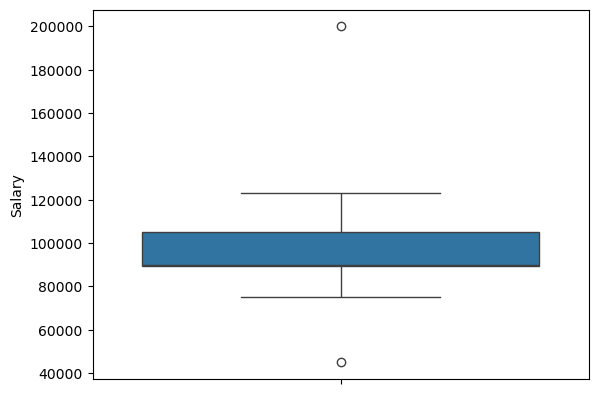

In [112]:
sns.boxplot(data.Salary)

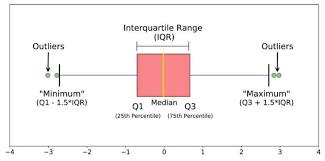

lower_boundary: minumum
upper_boundary: maximum

Minimum = (Q1+1.5)*IQR
Maximum =  (Q3-1.5)*IQR
IQR = Q3-Q1


In [136]:
Q1 = np.percentile(data.Salary, 25)

In [137]:
Q1

np.float64(89500.0)

In [138]:
Q3 = np.percentile(data.Salary, 75)
Q3

np.float64(105000.0)

In [139]:
IQR = Q3-Q1
IQR

np.float64(15500.0)

In [140]:
lb = Q1-1.5*IQR
ub = Q3+1.5*IQR

In [141]:
lb

np.float64(66250.0)

In [142]:
ub

np.float64(128250.0)

In [143]:
data[(data.Salary<=lb) | (data.Salary>=ub)]

,Emp_ID,Designation,Department,Age,Salary
0,1101,Manager,Accounts,50.0,200000.0
4,2123,Office Boy,Accounts,27.0,45000.0


In [144]:
def detect_outlier(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3-Q1
    lb = Q1-1.5*IQR
    ub = Q3+1.5*IQR
    return lb,ub  

In [148]:
detect_outlier(data.Salary)[0]
detect_outlier(data.Salary)[1]

np.float64(128250.0)

In [149]:
data[(data.Salary<=detect_outlier(data.Salary)[0]) | (data.Salary>=detect_outlier(data.Salary)[1])]

,Emp_ID,Designation,Department,Age,Salary
0,1101,Manager,Accounts,50.0,200000.0
4,2123,Office Boy,Accounts,27.0,45000.0


In [150]:
data[(data.Age<=detect_outlier(data.Age)[0]) | (data.Age>=detect_outlier(data.Age)[1])]

,Emp_ID,Designation,Department,Age,Salary


In [152]:
detect_outlier(data.Salary)

(np.float64(66250.0), np.float64(128250.0))

In [153]:
data[(data.Salary<=detect_outlier(data.Salary)[0] ) | (data.Salary>=detect_outlier(data.Salary)[1])]

,Emp_ID,Designation,Department,Age,Salary
0,1101,Manager,Accounts,50.0,200000.0
4,2123,Office Boy,Accounts,27.0,45000.0


In [154]:
np.array([1,2,3,4,5])

array([1, 2, 3, 4, 5])

In [155]:
data = pd.read_csv('car_data.csv')

In [156]:
data.shape

(892, 6)

In [157]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB


In [158]:
data.isna().sum()

name           0
company        0
year           0
Price          0
kms_driven    52
fuel_type     55
dtype: int64

In [159]:
data.duplicated().sum()

np.int64(94)

In [161]:
data.name.unique()

array(['Hyundai Santro Xing XO eRLX Euro III', 'Mahindra Jeep CL550 MDI',
       'Maruti Suzuki Alto 800 Vxi',
       'Hyundai Grand i10 Magna 1.2 Kappa VTVT',
       'Ford EcoSport Titanium 1.5L TDCi', 'Ford Figo', 'Hyundai Eon',
       'Ford EcoSport Ambiente 1.5L TDCi',
       'Maruti Suzuki Alto K10 VXi AMT', 'Skoda Fabia Classic 1.2 MPI',
       'Maruti Suzuki Stingray VXi', 'Hyundai Elite i20 Magna 1.2',
       'Mahindra Scorpio SLE BS IV', 'Audi A8', 'Audi Q7',
       'Mahindra Scorpio S10', 'Maruti Suzuki Alto 800',
       'Hyundai i20 Sportz 1.2', 'Maruti Suzuki Alto 800 Lx',
       'Maruti Suzuki Vitara Brezza ZDi', 'Maruti Suzuki Alto LX',
       'Mahindra Bolero DI', 'Maruti Suzuki Swift Dzire ZDi',
       'Mahindra Scorpio S10 4WD', 'Maruti Suzuki Swift Vdi BSIII',
       'Maruti Suzuki Wagon R VXi BS III',
       'Maruti Suzuki Wagon R VXi Minor',
       'Toyota Innova 2.0 G 8 STR BS IV', 'Renault Lodgy 85 PS RXL',
       'Skoda Yeti Ambition 2.0 TDI CR 4x2',
       'Maru

In [162]:
data.drop_duplicates(inplace=True)

In [163]:
data.shape

(798, 6)

In [182]:
data.name = data.name.str.split().str[0:3].str.join(' ')

In [168]:
s1 = pd.Series([11,22,33,44,55,66,77])

0    11
1    22
2    33
3    44
4    55
5    66
6    77
dtype: int64

In [169]:
s1[0:3]

0    11
1    22
2    33
dtype: int64

In [174]:
" ".join("hello python how are you".split()[:3])

'hello python how'

In [183]:
data

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium,Ford,2014,"5,75,000","36,000 kms",Diesel
...,...,...,...,...,...,...
887,Ta,Tara,zest,"3,10,000",NaN,NaN
888,Tata Zest XM,Tata,2018,"2,60,000","27,000 kms",Diesel
889,Mahindra Quanto C8,Mahindra,2013,"3,90,000","40,000 kms",Diesel
890,Honda Amaze 1.2,Honda,2014,"1,80,000",Petrol,NaN


In [185]:
data.year.unique()

array(['2007', '2006', '2018', '2014', '2015', '2012', '2013', '2016',
       '2010', '2017', '2008', '2011', '2019', '2009', '2005', '2000',
       '...', '150k', 'TOUR', '2003', 'r 15', '2004', 'Zest', '/-Rs',
       'sale', '1995', 'ara)', '2002', 'SELL', '2001', 'tion', 'odel',
       '2 bs', 'arry', 'Eon', 'o...', 'ture', 'emi', 'car', 'able', 'no.',
       'd...', 'SALE', 'digo', 'sell', 'd Ex', 'n...', 'e...', 'D...',
       ', Ac', 'go .', 'k...', 'o c4', 'zire', 'cent', 'Sumo', 'cab',
       't xe', 'EV2', 'r...', 'zest'], dtype=object)